In [2]:
!pip install seaborn matplotlib --quiet

# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


def generate_synthetic_record():
    sim_swap_time_gap_minutes = random.randint(0, 10080)  # up to 7 days
    device_change_flag = random.choice([0, 1])
    sim_type_change_flag = random.choice([0, 1])
    imsi_change_flag = random.choice([0, 1])
    iccid_change_flag = random.choice([0, 1])
    otp_and_sim_change_geo_hash_length = round(random.uniform(0.0, 1.0), 2)

    # New features
    recent_sim_activation_days = random.randint(0, 365)
    num_sim_changes_last_30d = random.randint(0, 5)
    previous_sim_holder_tenure_days = random.randint(0, 1095)  # Up to 3 years
    account_age_days = random.randint(1, 1825)  # Up to 5 years
    ip_change_flag = random.choice([0, 1])

    # Sim swap flag logic (simple heuristic)
    identity_shift_score = device_change_flag + sim_type_change_flag + imsi_change_flag + iccid_change_flag
    geo_risk_score = 1 - otp_and_sim_change_geo_hash_length
    time_urgency_score = 1 - min(sim_swap_time_gap_minutes, 10080) / 10080

    fraud_score = (
            0.3 * identity_shift_score +
            0.2 * geo_risk_score +
            0.2 * time_urgency_score +
            0.1 * (1 if recent_sim_activation_days < 7 else 0) +
            0.1 * (1 if num_sim_changes_last_30d >= 2 else 0) +
            0.1 * ip_change_flag
    )
    sim_swap_flag = 1 if fraud_score > 0.7 else 0

    return {
        "sim_swap_time_gap_minutes": sim_swap_time_gap_minutes,
        "device_change_flag": device_change_flag,
        "sim_type_change_flag": sim_type_change_flag,
        "imsi_change_flag": imsi_change_flag,
        "iccid_change_flag": iccid_change_flag,
        "otp_and_sim_change_geo_hash_length": otp_and_sim_change_geo_hash_length,
        "recent_sim_activation_days": recent_sim_activation_days,
        "num_sim_changes_last_30d": num_sim_changes_last_30d,
        "previous_sim_holder_tenure_days": previous_sim_holder_tenure_days,
        "account_age_days": account_age_days,
        "ip_change_flag": ip_change_flag,
        "sim_swap_flag": sim_swap_flag
    }


def generate_dataset(n=50000):
    return pd.DataFrame([generate_synthetic_record() for _ in range(n)])


if __name__ == "__main__":
    df = generate_dataset(50000)
    df.to_csv("sim_swap_fraud_dataset_50000.csv", index=False)
    print("Dataset with 50,000 records saved as 'sim_swap_fraud_dataset_50000.csv'")

Dataset with 50,000 records saved as 'sim_swap_fraud_dataset_50000.csv'


In [3]:
# 📊 Create dataset and feature
df = generate_dataset()
df["identity_shift_score"] = (
    df["device_change_flag"] +
    df["sim_type_change_flag"] +
    df["imsi_change_flag"] +
    df["iccid_change_flag"]
)

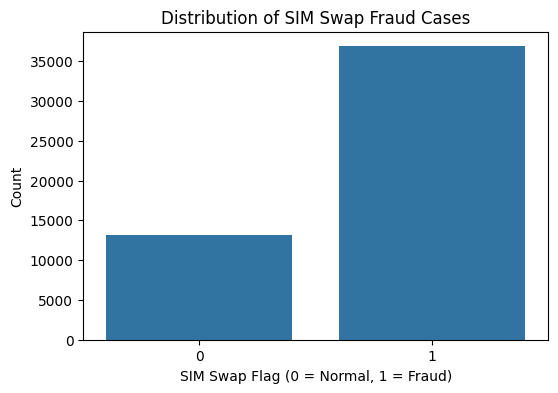

In [4]:
# ✅ 1. Fraud distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="sim_swap_flag", data=df)
plt.title("Distribution of SIM Swap Fraud Cases")
plt.xlabel("SIM Swap Flag (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()


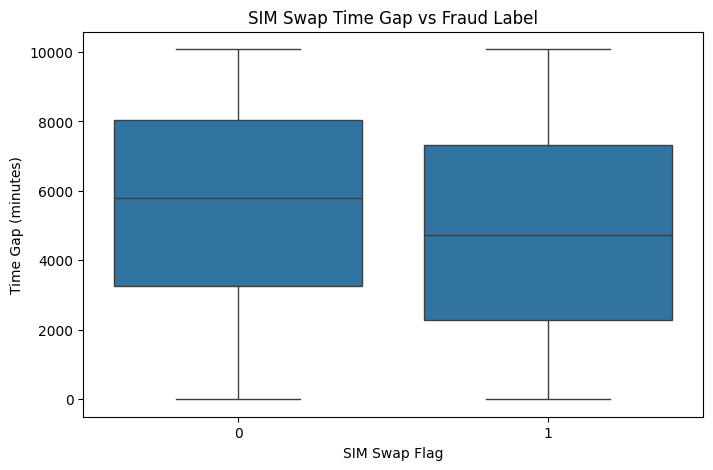

In [5]:
# ✅ 2. Time gap vs fraud label
plt.figure(figsize=(8, 5))
sns.boxplot(x="sim_swap_flag", y="sim_swap_time_gap_minutes", data=df)
plt.title("SIM Swap Time Gap vs Fraud Label")
plt.xlabel("SIM Swap Flag")
plt.ylabel("Time Gap (minutes)")
plt.show()

/tmp/ipython-input-708937315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sim_swap_flag", y="account_age_days", data=df, palette="muted")


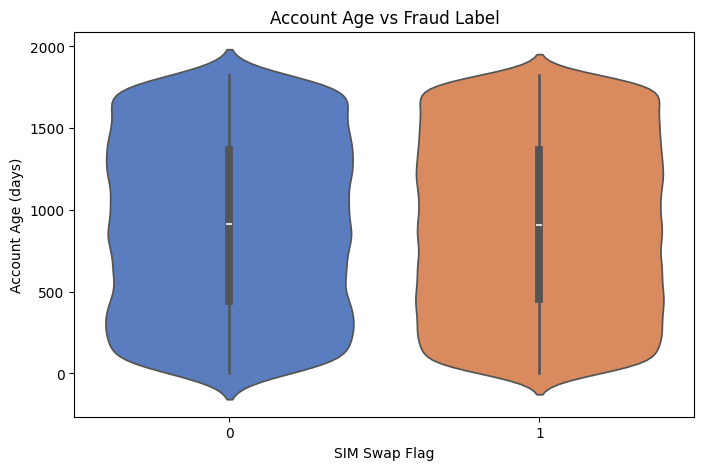

In [6]:
# ✅ 3. Account age vs fraud
plt.figure(figsize=(8, 5))
sns.violinplot(x="sim_swap_flag", y="account_age_days", data=df, palette="muted")
plt.title("Account Age vs Fraud Label")
plt.xlabel("SIM Swap Flag")
plt.ylabel("Account Age (days)")
plt.show()


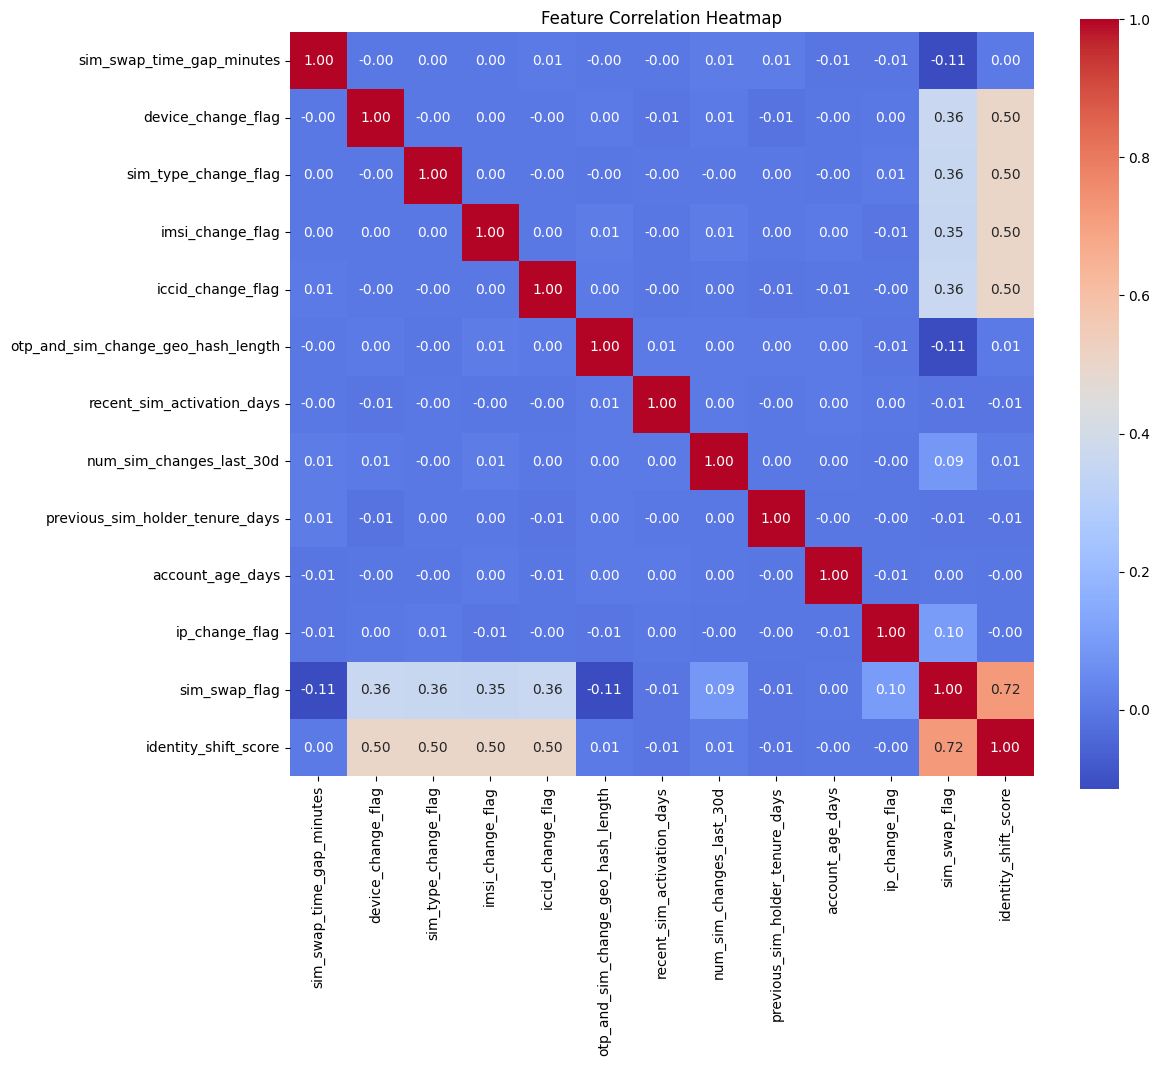

In [7]:
# ✅ 4. Feature correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

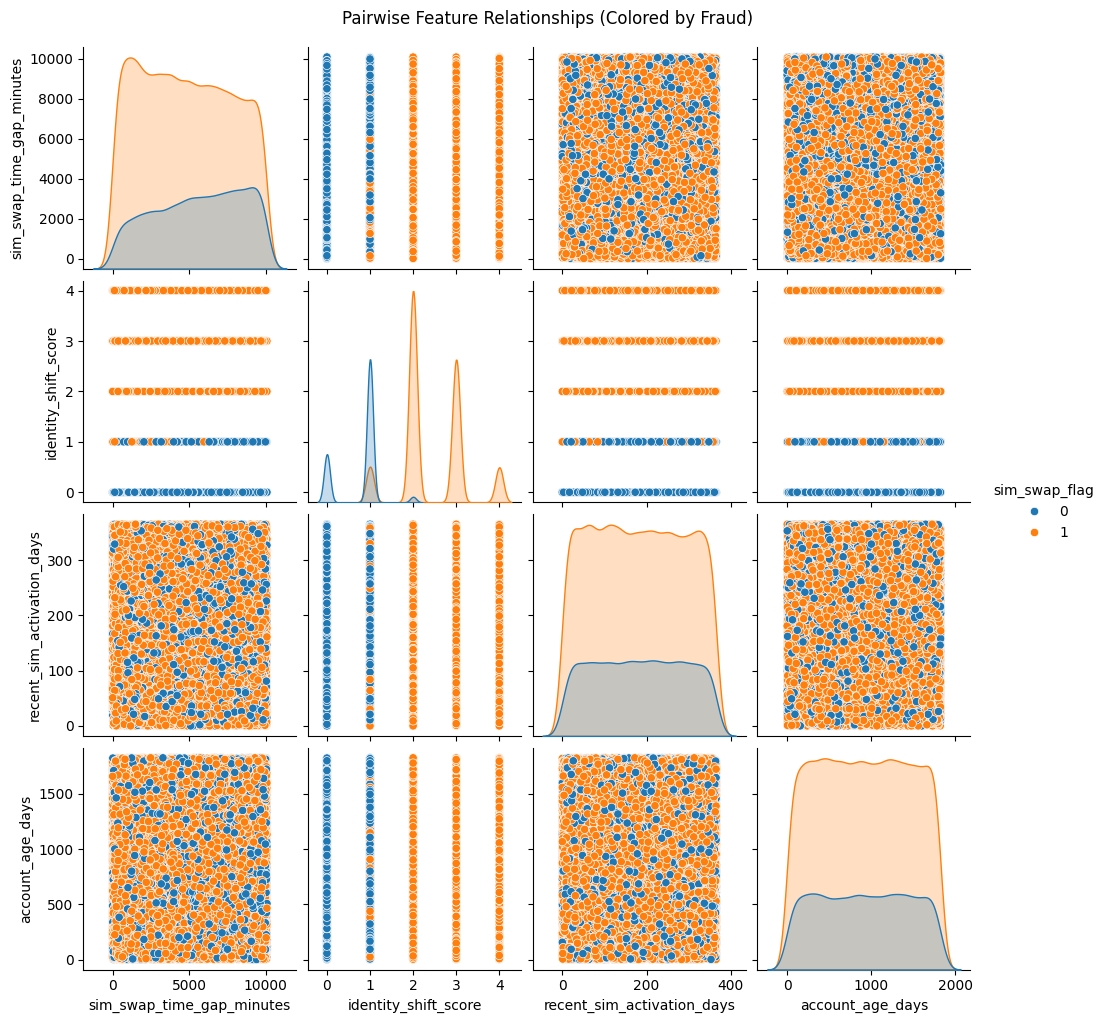

In [8]:
# ✅ 5. Pairplot of selected features
selected_features = [
    "sim_swap_time_gap_minutes",
    "identity_shift_score",
    "recent_sim_activation_days",
    "account_age_days",
    "sim_swap_flag"
]

# Clean data and convert to numeric
clean_df = df[selected_features].apply(pd.to_numeric, errors='coerce')
clean_df = clean_df.replace([np.inf, -np.inf], np.nan).dropna()
clean_df["sim_swap_flag"] = clean_df["sim_swap_flag"].astype(int)

sns.pairplot(clean_df, hue="sim_swap_flag", diag_kind="kde")
plt.suptitle("Pairwise Feature Relationships (Colored by Fraud)", y=1.02)
plt.show()